## movie chopping

this notebook contains code for dividing long movies into smaller chunks. this is a very slow process because it means copying and processing (maybe reencoding) long videos. even if the processing was very fast, it can only be as fast as the storage drive.

## chopper
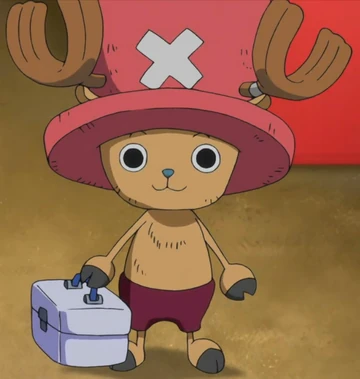

the chopper takes the output of the scraper and cuts movies into approximately 10 minute clips. the code tries to copy the movie stream but if it fails it tries to reencode the movie in a very low but fast quality compression. this is because on an old pentium duo pc that i was running this on i had problem with copying of some movies.

## important
this code uses ffmpeg binary through the command line. this code is not protable on non unix systems and systems that do not have ffmpeg installed.

this is because is had problems with installing the `python-python-ffmpeg` library in my system (linux) for some reason. this is a massive skill issue :(

---


the chopper needs a bunch of files and settings before it can start working.

In [1]:
from dataclasses import dataclass
from multiprocessing import cpu_count

@dataclass
class Options:
    # where is the jsonl produced in the movie analisis stage
    jsonl_file: str

    # where to sture the created videos
    output_dir: str

    # where to store metadata of the videos
    dataset_jsonl: str

    # the scraper stores relative paths to movies
    # so this is the root directory of the movies
    base_dir: str

    # approximate clip duration in seconds
    clip_duration: int = 600
    
    # number of threads to work with
    workers: int = cpu_count()


### small helper functions

ffmpeg somethimes fails because of an invalid movie name.
this function takes the movie name and makes a better version for ffmpeg.

replaces all characters that are not `letters|numbers|_|.|space` with `_`

In [2]:
import re

def safe_name(name):
    return re.sub(r'[^\w\-_\. ]', '_', name)

make running ffmpeg less painfull

In [3]:
import os
import subprocess

def run_ffmpeg(cmd):
    return subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=True, preexec_fn=lambda: os.nice(10))


### copy or reencode

try to just copy the video (this should be as fast as the disk is) and if it fails try to reencode in x264 on the fastest settings.

In [4]:
import subprocess

def reencode_and_segment(video_input, output_pattern):

    try:
        run_ffmpeg([
            "ffmpeg", "-y", "-i", video_input,
            "-c", "copy", "-f", "segment",
            "-segment_time", str(clip_duration),
            "-reset_timestamps", "1",
            output_pattern
        ])
        return "copy"
    except subprocess.CalledProcessError:
        pass  
    
    try:
        run_ffmpeg([
            "ffmpeg", "-y",
            "-i", video_input,
            "-c:v", "libx264",
            "-preset", "ultrafast", "-crf", "28",
            "-c:a", "aac", "-b:a", "128k",
            "-f", "segment", "-segment_time", str(clip_duration),
            "-reset_timestamps", "1",
            output_pattern
        ])
        return "reencode"
    except subprocess.CalledProcessError:
        return None


### process one movie

take one file from the dataset. divide it into smaller clips and store them as `title_year_clipnum.mkv`


In [5]:
import json
import os

def process_movie(film, options):
    safe_title = safe_name(film['title'])
    dir_name = f"{safe_title} ({film['year']})"
    dir_path = os.path.join(options.output_dir, dir_name)
    os.makedirs(folder_path, exist_ok=True)

    video_input = film['file_path']
    video_input = os.path.join(options.base_dir, video_input)

    if not os.path.isfile(video_input):
        print(f"video not found: {video_input}")
        return 0
    
    print(f"processing video: {video_input}")

    output_pattern = os.path.join(dir_path, f"{safe_title}_{film['year']}_%03d.mkv")

    result = reencode_and_segment(video_input, output_pattern)
    if result == "copy":
        print(f"success (stream copy): {film['title']}")
    elif result == "reencode":
        print(f"success (reencode): {film['title']}")
    else:
        print(f"failed: {film['title']}")
        return 0

    video_extensions = (".mkv", ".mp4", ".mov", ".avi", ".flv", ".wmv", ".m4v", ".webm")
    clips = sorted(
        f for f in os.listdir(dir_path)
        if f.lower().endswith(video_extensions)
    )
    count = 0
    with open(dataset_jsonl_path, 'a', encoding='utf-8') as out_f:
        for clip_file in clips:
            clip_path_abs = os.path.join(dir_path, clip_file)
            clip_path_rel = os.path.relpath(clip_path_abs, options.output_dir)
            entry = {
                "csfd_id": film.get("csfd_id"),
                "title": film.get("title"),
                "year": film.get("year"),
                "genres": film.get("genres", []),
                "clip_path": clip_path_rel
            }
            json.dump(entry, out_f, ensure_ascii=False)
            out_f.write('\n')
            count += 1
    return count

### process the whole dataset

In [6]:
from multiprocessing import Pool
import json

def process(options):
    movies = []
    with open(options.jsonl_file, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                movies.append(json.loads(line))

    total_clips = 0

    open(options.dataset_jsonl, 'w').close()

    with Pool(processes=options.workers) as pool:
        results = pool.starmap(
            process_movie,
            [(film, options) for film in movies]
        )
        total_clips = sum(results)
    
    print(f"total clips processed: {total_clips}")